In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path_manual = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"
# file_path_AI = r"D:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\first_try"
file_path_AI = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\all_files_20260310T183229"
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"

In [3]:
manual_wttest = pd.read_csv(f'{file_path_manual}\drugs_dysregulation_summary_Ttest.csv',index_col = 0)

ai_wttest = pd.read_csv(f'{file_path_AI}\DE_summary_all_drugs.csv')

In [4]:
file_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\files"
df_filter = pd.read_csv(f'{file_path}\drug_names_replaced_filtered_raw_clean.csv', index_col = 0)

In [5]:
import mygene

mg = mygene.MyGeneInfo()

uniprot_ids = [item.split("cRAP-")[-1] for item in df_filter.index]

res2 = mg.querymany(
    uniprot_ids,
    scopes='uniprot',
    fields='symbol',
    species='human'
)

df_map = pd.DataFrame(res2)

# 3) 清洗：没找到 / 没有 symbol 的统一填 "No"
if "symbol" not in df_map.columns:
    df_map["symbol"] = None

df_map["symbol"] = df_map["symbol"].where(df_map["symbol"].notna(), other="No")
if "notfound" in df_map.columns:
    df_map.loc[df_map["notfound"] == True, "symbol"] = "No"

# 4) 保证一对一：同一个 query 如果出现多条，优先保留有 symbol 的那条
df_map["_is_no_"] = (df_map["symbol"] == "No").astype(int)
df_map = (
    df_map.sort_values(["query", "_is_no_"])
          .drop_duplicates(subset=["query"], keep="first")
          .drop(columns=["_is_no_"])
)

# 5) 建立映射 dict：query(uniprot) -> symbol(gene)
map_dict = dict(zip(df_map["query"].astype(str), df_map["symbol"].astype(str)))

INFO:biothings.client:querying 1-1000...
INFO:biothings.client:done.
INFO:biothings.client:querying 1001-2000...
INFO:biothings.client:done.
INFO:biothings.client:querying 2001-3000...
INFO:biothings.client:done.
INFO:biothings.client:querying 3001-4000...
INFO:biothings.client:done.
INFO:biothings.client:querying 4001-5000...
INFO:biothings.client:done.
INFO:biothings.client:querying 5001-6000...
INFO:biothings.client:done.
INFO:biothings.client:querying 6001-7000...
INFO:biothings.client:done.
INFO:biothings.client:querying 7001-8000...
INFO:biothings.client:done.
INFO:biothings.client:querying 8001-8146...
INFO:biothings.client:done.
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [6]:
# df_map.to_csv(f'{file_path}/uniprot_to_gene.csv')

In [7]:
# 可选：看看映射表
print(df_map[["query", "symbol"]].head())

        query   symbol
0  A0A096LP01   SMIM26
1  A0A1W2PQ72  MSANTD7
2  A0A6Q8PH20     CAST
3  A0A804HLA8    GNG5B
4  A0AAG2UWQ9     NKRF


In [8]:
df_map[df_map["symbol"] == "HMGCR"]

,query,_id,_score,symbol,notfound
1082,P04035,3156,20.076271,HMGCR,NaN


In [9]:
# 6) 给“另外一个 dataframe”加 gene 列
#    - 假设 df_other.index 也是 uniprot 或含 cRAP- 前缀
uniprot_other = [str(item).split("cRAP-")[-1] for item in manual_wttest.protein]
manual_wttest["gene"] = [map_dict.get(uid, "No") for uid in uniprot_other]

manual_wttest

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj,gene
0,A0A096LP01,6-Mercaptopurine,-2.113386,7.665441e-02,19.442643,19.655949,-0.213306,0.182348,SMIM26
1,A0A1W2PQ72,6-Mercaptopurine,0.388856,7.076332e-01,13.956303,13.840781,0.115522,0.820512,MSANTD7
2,A0A6Q8PH20,6-Mercaptopurine,5.473972,1.167830e-05,24.329154,24.179239,0.149915,0.000245,CAST
3,A0A804HLA8,6-Mercaptopurine,-1.632129,1.527133e-01,15.289839,16.555034,-1.265195,0.298380,GNG5B
4,A0AAG2UWQ9,6-Mercaptopurine,-1.168956,2.593294e-01,22.127657,22.167910,-0.040252,0.429875,NKRF
...,...,...,...,...,...,...,...,...,...
1384815,cRAP-O77727,DFO,3.002222,4.628480e-03,24.828922,24.140402,0.688520,0.022427,No
1384816,cRAP-P00761,DFO,5.864143,5.434324e-07,32.340354,31.608482,0.731872,0.000024,No
1384817,cRAP-P02769,DFO,-4.605658,4.137180e-05,27.403938,27.988360,-0.584423,0.000631,No
1384818,cRAP-P12763,DFO,0.225953,8.224648e-01,30.061601,30.039859,0.021742,0.896596,No


In [10]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

ai_wttest["p_value_adj"] = multipletests(
    ai_wttest["p_value"],
    method="fdr_bh"
)[1]
ai_wttest

,ProteinID,Drug,log2FC,t_statistic,p_value,FDR,significant,Gene,p_value_adj
0,A0A096LP01,Triclabendazole,0.255210,2.826782,2.662151e-02,0.073536,False,SMIM26,0.083719
1,A0A1W2PQ72,Triclabendazole,0.257456,1.386143,1.825797e-01,0.313735,False,MSANTD7,0.337969
2,A0A6Q8PH20,Triclabendazole,-0.124206,-4.868808,4.354102e-05,0.000628,False,CAST,0.000656
3,A0A804HLA8,Triclabendazole,0.354778,1.394210,1.753126e-01,0.304551,False,GNG5B,0.328582
4,A0AAG2UWQ9,Triclabendazole,-0.086536,-2.801851,1.052918e-02,0.036053,False,NKRF,0.041720
...,...,...,...,...,...,...,...,...,...
1384815,cRAP-O77727,Deferoxamine(DFO),0.688520,3.002222,4.628480e-03,0.007539,True,cRAP_KRT15,0.022427
1384816,cRAP-P00761,Deferoxamine(DFO),0.731872,5.864143,5.434324e-07,0.000002,True,cRAP_P00761,0.000024
1384817,cRAP-P02769,Deferoxamine(DFO),-0.584423,-4.605658,4.137180e-05,0.000095,True,cRAP_ALB,0.000631
1384818,cRAP-P12763,Deferoxamine(DFO),0.021742,0.225953,8.224648e-01,0.847539,False,cRAP_AHSG,0.896596


In [11]:
# 6) 给“另外一个 dataframe”加 gene 列
#    - 假设 df_other.index 也是 uniprot 或含 cRAP- 前缀

ai_wttest = ai_wttest.rename(columns={
    "ProteinID": "protein",
    "Drug": "drug"
})

uniprot_other2 = [str(item).split("cRAP-")[-1] for item in ai_wttest.protein]
ai_wttest["gene"] = [map_dict.get(uid, "No") for uid in uniprot_other2]

ai_wttest

,protein,drug,log2FC,t_statistic,p_value,FDR,significant,Gene,p_value_adj,gene
0,A0A096LP01,Triclabendazole,0.255210,2.826782,2.662151e-02,0.073536,False,SMIM26,0.083719,SMIM26
1,A0A1W2PQ72,Triclabendazole,0.257456,1.386143,1.825797e-01,0.313735,False,MSANTD7,0.337969,MSANTD7
2,A0A6Q8PH20,Triclabendazole,-0.124206,-4.868808,4.354102e-05,0.000628,False,CAST,0.000656,CAST
3,A0A804HLA8,Triclabendazole,0.354778,1.394210,1.753126e-01,0.304551,False,GNG5B,0.328582,GNG5B
4,A0AAG2UWQ9,Triclabendazole,-0.086536,-2.801851,1.052918e-02,0.036053,False,NKRF,0.041720,NKRF
...,...,...,...,...,...,...,...,...,...,...
1384815,cRAP-O77727,Deferoxamine(DFO),0.688520,3.002222,4.628480e-03,0.007539,True,cRAP_KRT15,0.022427,No
1384816,cRAP-P00761,Deferoxamine(DFO),0.731872,5.864143,5.434324e-07,0.000002,True,cRAP_P00761,0.000024,No
1384817,cRAP-P02769,Deferoxamine(DFO),-0.584423,-4.605658,4.137180e-05,0.000095,True,cRAP_ALB,0.000631,No
1384818,cRAP-P12763,Deferoxamine(DFO),0.021742,0.225953,8.224648e-01,0.847539,False,cRAP_AHSG,0.896596,No


# plot dysregulation compare
### 注意这里最后的图片中需要高亮几个后续故事中重点描述的典型药物

In [12]:
import pandas as pd

def summarize_dysregulation_counts(
    df_vari: pd.DataFrame,
    drug_col: str = "drug",
    log2fc_col: str = "log2FC",
    p_adj_col: str = "p_value_adj",
    fdr_thresh: float = 0.05,
    fc_thresh: float = 0.5,
    include_total: bool = True,
    keep_all_drugs: bool = False,
) -> pd.DataFrame:
    """
    Summarize significant dysregulation counts (up/down) per drug.

    Parameters
    ----------
    df_vari : pd.DataFrame
        Input dataframe with at least [drug_col, log2fc_col, p_adj_col].
    drug_col, log2fc_col, p_adj_col : str
        Column names for drug, log2FC, and adjusted p-value/FDR.
    fdr_thresh : float
        Significance threshold on adjusted p-value (e.g., 0.05).
    fc_thresh : float
        Absolute log2FC threshold for calling up/down (e.g., 0.5).
    include_total : bool
        If True, include "total" as number of significant rows per drug.
    keep_all_drugs : bool
        If True, include all drugs from df_vari (even those with zero significant hits),
        filling counts with 0.

    Returns
    -------
    pd.DataFrame
        Columns: [drug_col, up, down, sig_dys, (total)]
    """
    required = {drug_col, log2fc_col, p_adj_col}
    missing = required - set(df_vari.columns)
    if missing:
        raise ValueError(f"df_vari is missing required columns: {sorted(missing)}")

    # Filter significant rows
    sig = df_vari.loc[df_vari[p_adj_col] < fdr_thresh, [drug_col, log2fc_col]].copy()

    # If nothing is significant, return an empty (or all-drug) summary
    if sig.empty:
        if keep_all_drugs:
            drugs = pd.Index(df_vari[drug_col].dropna().unique(), name=drug_col)
            out = pd.DataFrame({drug_col: drugs, "up": 0, "down": 0, "sig_dys": 0})
            if include_total:
                out["total"] = 0
            return out.reset_index(drop=True)
        cols = [drug_col, "up", "down", "sig_dys"] + (["total"] if include_total else [])
        return pd.DataFrame(columns=cols)

    # Compute counts per drug
    grp = sig.groupby(drug_col, dropna=False)[log2fc_col]
    summary = grp.agg(
        up=lambda x: (x > fc_thresh).sum(),
        down=lambda x: (x < -fc_thresh).sum(),
        total="size",
    ).reset_index()

    # Add up + down
    summary["sig_dys"] = summary["up"] + summary["down"]

    if not include_total:
        summary = summary.drop(columns=["total"])

    if keep_all_drugs:
        all_drugs = pd.Index(df_vari[drug_col].dropna().unique(), name=drug_col)
        summary = (
            pd.DataFrame({drug_col: all_drugs})
            .merge(summary, on=drug_col, how="left")
            .fillna(0)
        )
        for c in ["up", "down", "sig_dys"] + (["total"] if include_total else []):
            summary[c] = summary[c].astype(int)

    return summary

In [13]:
#  "P 值 < 0.05, log2FC > 0.5"

In [14]:
summary_ai = summarize_dysregulation_counts(ai_wttest)
summary_manual = summarize_dysregulation_counts(manual_wttest)

In [15]:
summary_ai

,drug,up,down,total,sig_dys
0,6-Mercaptopurine,275,311,3082,586
1,ATP (dimagnesium),105,55,1988,160
2,Abemaciclib (methanesulfonate),749,1424,4293,2173
3,Acetophenazine (dimaleate),358,38,2898,396
4,Adiphenine (hydrochloride),61,32,1588,93
...,...,...,...,...,...
165,Vecuronium (bromide),48,8,699,56
166,Vemurafenib,374,311,3069,685
167,Zanubrutinib,76,61,1954,137
168,Î±-Lipoic Acid,101,34,2347,135


In [16]:
summary_manual[summary_manual["drug"] ==  "Methylene blue (trihydrate)" ]

,drug,up,down,total,sig_dys
109,Methylene blue (trihydrate),355,590,3616,945


In [28]:
# summary_manual

In [27]:
# summary_manual.sort_values(by="sig_dys")

In [19]:
[item for item in summary_manual.drug if "ravirine" in item ]

['Etravirine']

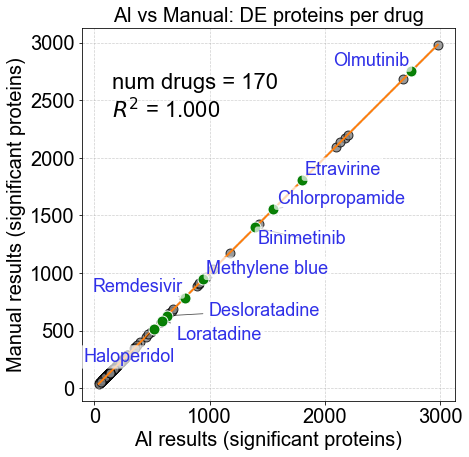

In [22]:
from adjustText import adjust_text
import re

# 1) merge by drug, get X (AI) and Y (manual)
df_pair = (
    summary_ai[["drug", "sig_dys"]].rename(columns={"sig_dys": "total_ai"})
    .merge(
        summary_manual[["drug", "sig_dys"]].rename(columns={"sig_dys": "total_manual"}),
        on="drug",
        how="inner",
    )
    .dropna(subset=["total_ai", "total_manual"])
)

x = df_pair["total_ai"].astype(float).to_numpy()
y = df_pair["total_manual"].astype(float).to_numpy()

# 2) plot
plt.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(x, y, s=80, alpha=0.8, edgecolors="black", color = "#808080")

# y = x line
mn = float(np.min([x.min(), y.min()]))
mx = float(np.max([x.max(), y.max()]))
ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5)

# linear fit line + R^2
if len(x) >= 2:
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, slope * xs + intercept, linewidth=2)

    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
else:
    r2 = np.nan
# --- Highlight + label selected drugs (case-insensitive) ---
highlight_drugs = [
    "Remdesivir",
    "Chlorpropamide",
    "Loratadine",
    "Haloperidol",
    "Methylene blue (trihydrate)",
    "Desloratadine",
    "Binimetinib",
    "Etravirine",
    "Olmutinib",
]

# case-insensitive helper columns
df_pair["drug_u"] = df_pair["drug"].astype(str).str.strip().str.upper()
highlight_u = [d.strip().upper() for d in highlight_drugs]

df_h = df_pair[df_pair["drug_u"].isin(highlight_u)].copy()

# (optional) print which ones are missing
missing = [d for d in highlight_u if d not in set(df_h["drug_u"])]
if missing:
    print("Not found in df_pair (check spelling/case):", missing)

# 1) highlight points (filled)
ax.scatter(
    df_h["total_ai"].astype(float),
    df_h["total_manual"].astype(float),
    s=120,
    color="green",
    edgecolors="white",
    linewidths=1.0,
    alpha=0.95,
    zorder=6
)

# 2) add labels
texts = []
for _, r in df_h.iterrows():
    clean_label = re.sub(r"\s*\(.*?\)\s*$", "", str(r["drug"])).strip()

    texts.append(
        ax.text(
            float(r["total_ai"]),
            float(r["total_manual"]),
            clean_label,
            fontsize=18,
            ha="left",
            va="bottom",
            zorder=10,
            color="#3030E8",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
        )
    )

# 3) reduce overlap (recommended)
try:
    from adjustText import adjust_text
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.7)
    )
except Exception:
    print("Tip: labels overlap? install adjustText: pip install adjustText")    
numer = 20
# cosmetics
ax.set_xlabel("AI results (significant proteins)", fontsize=numer)
ax.set_ylabel("Manual results (significant proteins)", fontsize=numer)
ax.set_title("AI vs Manual: DE proteins per drug", fontsize=numer)
ax.tick_params(axis="both", labelsize=numer)
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_aspect("equal", adjustable="box")

# annotation
ax.text(
    0.08, 0.88,
    f"num drugs = {len(summary_manual)}\n$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=22,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.1),
)
plt.savefig(f'{figure_path}/AIvsManual_DE proteins per drug.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [23]:
[item for item in summary_manual.drug if "Atorvastatin" in item]

['Atorvastatin (hemicalcium salt)']

# plot log2 FC compare
### 注意这里最后的图片中需要高亮几个后续故事中提到的典型蛋白或者通路。

In [24]:
drug_name = "Loratadine" 
need_cols = ["protein", "log2FC", "drug"]
ai_wttest.loc[ai_wttest["drug"] == drug_name, need_cols].copy()

,protein,log2FC,drug
195504,A0A096LP01,0.066012,Loratadine
195505,A0A1W2PQ72,0.290497,Loratadine
195506,A0A6Q8PH20,0.012755,Loratadine
195507,A0A804HLA8,0.805535,Loratadine
195508,A0AAG2UWQ9,-0.056242,Loratadine
...,...,...,...
203645,cRAP-O77727,0.425372,Loratadine
203646,cRAP-P00761,0.202207,Loratadine
203647,cRAP-P02769,0.222290,Loratadine
203648,cRAP-P12763,-0.735161,Loratadine


In [25]:
# man_sub.sort_values(by = "log2FC")

Not found in df_pair (check spelling/case): ['P12345']


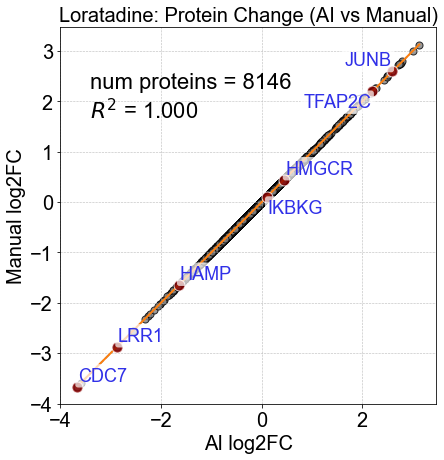

In [26]:
# ====== choose one drug ======
drug_name = "Loratadine"   # <- change to your drug

# ====== subset from raw dfs ======
need_cols = ["protein", "log2FC", "drug"]

ai_sub = ai_wttest.loc[ai_wttest["drug"] == drug_name, need_cols].copy()
man_sub = manual_wttest.loc[manual_wttest["drug"] == drug_name, need_cols].copy()

# merge by protein so X/Y are aligned
df_pair = (
    ai_sub.rename(columns={"log2FC": "log2FC_ai"})
    .merge(
        man_sub.rename(columns={"log2FC": "log2FC_manual"}),
        on=["protein", "drug"],
        how="inner",
    )
    .dropna(subset=["log2FC_ai", "log2FC_manual"])
)

x = df_pair["log2FC_ai"].astype(float).to_numpy()
y = df_pair["log2FC_manual"].astype(float).to_numpy()

# ====== scatter plot ======
plt.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(x, y, s=50, alpha=0.8, edgecolors="black", color = "#808080")

# identity line y=x
mn = float(np.min([x.min(), y.min()]))
mx = float(np.max([x.max(), y.max()]))
ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5)

# fit line + R^2
if len(x) >= 2:
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, slope * xs + intercept, linewidth=2)

    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
else:
    r2 = np.nan
    
# --- highlight + label selected proteins ---
highlight_proteins = [
    "P12345",   # <- 换成你要标记的 protein name / UniProt / gene symbol
    "Q9Y6K9",
    "P81172",
    "Q92754",
    "P17275",
    "P04035",
    "O00311",
    "Q96L50",  
]

# case-insensitive matching (recommended)
df_pair["protein_u"] = df_pair["protein"].astype(str).str.strip().str.upper()
highlight_u = [p.strip().upper() for p in highlight_proteins]

df_h = df_pair[df_pair["protein_u"].isin(highlight_u)].copy()

# (optional) print missing proteins
missing = [p for p in highlight_u if p not in set(df_h["protein_u"])]
if missing:
    print("Not found in df_pair (check spelling/case):", missing)

# 1) highlight points (filled)
ax.scatter(
    df_h["log2FC_ai"].astype(float),
    df_h["log2FC_manual"].astype(float),
    s=120,
    color="darkred",
    edgecolors="white",
    linewidths=1.0,
    alpha=0.8,
    zorder=6
)

# 统一大小写，避免大小写导致映射失败
map_dict_u = {str(k).strip().upper(): str(v) for k, v in map_dict.items()}  # 基因到uniprot ID 的映射

def to_gene_label(pid: str) -> str:
    k = str(pid).strip().upper()
    return map_dict_u.get(k, pid)  # 映射不到就用原 protein

# 2) add labels (use gene name)
texts = []
for _, r in df_h.iterrows():
    label = to_gene_label(r["protein"])
    texts.append(
        ax.text(
            float(r["log2FC_ai"]),
            float(r["log2FC_manual"]),
            label,         # <- gene name (fallback protein)
            fontsize=18,
            ha="left",
            va="bottom",
            zorder=10,
            color="#3030E8",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
        )
    )
# 3) reduce overlap (recommended)
try:
    from adjustText import adjust_text
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.7)
    )
except Exception:
    print("Tip: labels overlap? install adjustText: pip install adjustText")
    
# cosmetics
numer = 20
ax.set_xlabel("AI log2FC", fontsize=numer)
ax.set_ylabel("Manual log2FC", fontsize=numer)
ax.set_title(f"{drug_name}: Protein Change (AI vs Manual)", fontsize=20)
ax.tick_params(axis="both", labelsize=numer)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.8)
ax.set_aspect("equal", adjustable="box")

ax.text(
    0.08, 0.88,
    f"num proteins = {len(ai_sub)}\n$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=22,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.1),
)

plt.tight_layout()
plt.savefig(f'{figure_path}/{drug_name}_protein_log2FC_AIvsManual.svg', dpi=600, bbox_inches='tight')
plt.show()

In [42]:
# function for plot_ai_vs_manual_protein_scatter
import os

def plot_ai_vs_manual_protein_scatter(
    drug_name,
    highlight_proteins,
    ai_wttest,
    manual_wttest,
    map_dict,
    figure_path,
    protein_col="protein",
    fc_col="log2FC",
    drug_col="drug",
    show_fig=True,
):
    """
    Plot AI vs Manual log2FC scatter for one drug, highlight selected proteins,
    save figure, and return only R^2.

    Parameters
    ----------
    drug_name : str
        Drug name to plot.
    highlight_proteins : list
        List of proteins to highlight.
    ai_wttest : pd.DataFrame
        DataFrame containing AI results.
    manual_wttest : pd.DataFrame
        DataFrame containing manual results.
    map_dict : dict
        Mapping dictionary from protein ID -> gene name.
    figure_path : str
        Folder path for saving figure.
    protein_col : str, default "protein"
        Protein column name.
    fc_col : str, default "log2FC"
        log2FC column name.
    drug_col : str, default "drug"
        Drug column name.
    show_fig : bool, default True
        Whether to display figure.

    Returns
    -------
    r2 : float
        R-squared value of linear fit.
    """

    need_cols = [protein_col, fc_col, drug_col]

    ai_sub = ai_wttest.loc[ai_wttest[drug_col] == drug_name, need_cols].copy()
    man_sub = manual_wttest.loc[manual_wttest[drug_col] == drug_name, need_cols].copy()

    df_pair = (
        ai_sub.rename(columns={fc_col: "log2FC_ai"})
        .merge(
            man_sub.rename(columns={fc_col: "log2FC_manual"}),
            on=[protein_col, drug_col],
            how="inner",
        )
        .dropna(subset=["log2FC_ai", "log2FC_manual"])
    )

    if df_pair.empty:
        raise ValueError(f"No overlapping proteins found for drug: {drug_name}")

    x = df_pair["log2FC_ai"].astype(float).to_numpy()
    y = df_pair["log2FC_manual"].astype(float).to_numpy()

    plt.rcParams["font.family"] = "Arial"
    fig, ax = plt.subplots(figsize=(6.5, 6.5))

    # base scatter
    ax.scatter(x, y, s=50, alpha=0.8, edgecolors="black", color="#808080")

    # identity line
    mn = float(np.min([x.min(), y.min()]))
    mx = float(np.max([x.max(), y.max()]))
    ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5)

    # fit line + R2
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, slope * xs + intercept, linewidth=2)

        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    else:
        r2 = np.nan

    # highlight proteins
    df_pair["protein_u"] = df_pair[protein_col].astype(str).str.strip().str.upper()
    highlight_u = [str(p).strip().upper() for p in highlight_proteins]
    df_h = df_pair[df_pair["protein_u"].isin(highlight_u)].copy()

    missing = [p for p in highlight_u if p not in set(df_h["protein_u"])]
    if missing:
        print("Not found in df_pair (check spelling/case):", missing)

    # highlighted points
    if not df_h.empty:
        ax.scatter(
            df_h["log2FC_ai"].astype(float),
            df_h["log2FC_manual"].astype(float),
            s=120,
            color="darkred",
            edgecolors="white",
            linewidths=1.0,
            alpha=0.8,
            zorder=6
        )

    # mapping labels
    map_dict_u = {str(k).strip().upper(): str(v) for k, v in map_dict.items()}

    def to_gene_label(pid):
        k = str(pid).strip().upper()
        return map_dict_u.get(k, pid)

    texts = []
    for _, r in df_h.iterrows():
        label = to_gene_label(r[protein_col])
        texts.append(
            ax.text(
                float(r["log2FC_ai"]),
                float(r["log2FC_manual"]),
                label,
                fontsize=18,
                ha="left",
                va="bottom",
                zorder=10,
                color="#3030E8",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
            )
        )

    try:
        from adjustText import adjust_text
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.7)
        )
    except Exception:
        print("Tip: labels overlap? install adjustText: pip install adjustText")

    # cosmetics
    numer = 20
    ax.set_xlabel("AI log2FC", fontsize=numer)
    ax.set_ylabel("Manual log2FC", fontsize=numer)
    ax.set_title(f"{drug_name}: Protein Change (AI vs Manual)", fontsize=20)
    ax.tick_params(axis="both", labelsize=numer)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.8)
    ax.set_aspect("equal", adjustable="box")

    ax.text(
        0.08, 0.88,
        f"num proteins = {len(df_pair)}\n$R^2$ = {r2:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=22,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.1),
    )

    plt.tight_layout()

    os.makedirs(figure_path, exist_ok=True)
    out_file = os.path.join(figure_path, f"{drug_name}_protein_log2FC_AIvsManual.svg")
    plt.savefig(out_file, dpi=600, bbox_inches="tight")

    if show_fig:
        plt.show()
    else:
        plt.close(fig)

    return r2

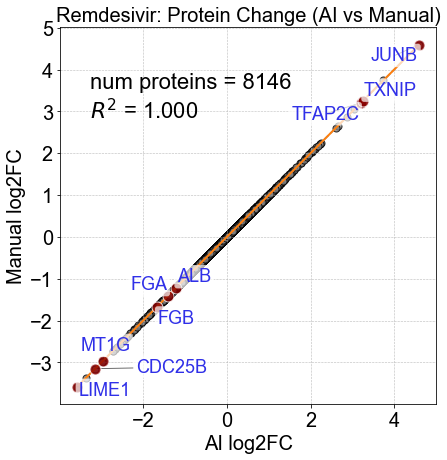

1.0

In [46]:
plot_ai_vs_manual_protein_scatter(
    drug_name="Remdesivir",
    highlight_proteins=[
        "Q9H400",
        "P30305",
        "P13640",
        "Q92754",
        "P17275",
        "P02768",
        "Q9H3M7",
        "P02671",
        "P02675"  
    ],
    ai_wttest=ai_wttest,
    manual_wttest=manual_wttest,
    map_dict=map_dict,
    figure_path=figure_path,
    show_fig=True
)

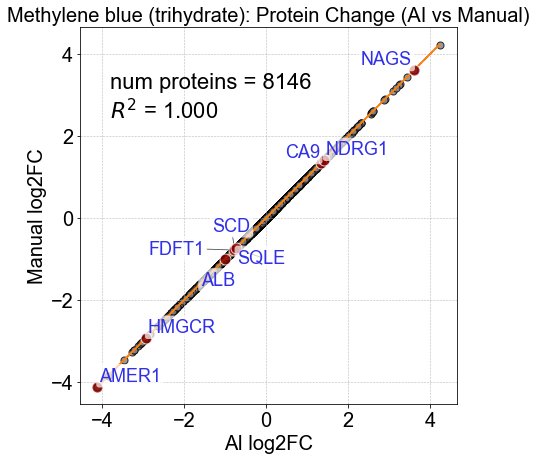

1.0

In [55]:
plot_ai_vs_manual_protein_scatter(
    drug_name="Methylene blue (trihydrate)",
    highlight_proteins=[
        "P04035",
        "Q14534",
        "P37268",
        "O00767",
        "Q92597",
        "Q16790",
        "Q5JTC6",
        "Q8N159",
        "P02768" 
    ],
    ai_wttest=ai_wttest,
    manual_wttest=manual_wttest,
    map_dict=map_dict,
    figure_path=figure_path,
    show_fig=True
)

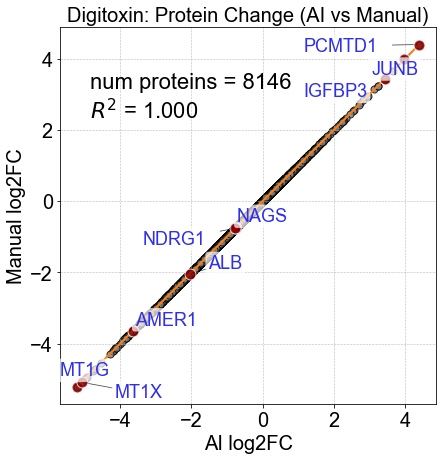

1.0

In [60]:
plot_ai_vs_manual_protein_scatter(
    drug_name="Digitoxin",
    highlight_proteins=[
        "P13640",
        "P80297",
        "P17275",
        "P17936",
        "Q5JTC6",
        "Q8N159",
        "P02768", 
        "Q92597",
        "Q8N159",
        "P02768",
        "Q96MG8"
    ],
    ai_wttest=ai_wttest,
    manual_wttest=manual_wttest,
    map_dict=map_dict,
    figure_path=figure_path,
    show_fig=True
)

In [56]:
drug_name = "Digitoxin" 
need_cols = ["protein", "log2FC", "drug","Gene"]
slice_drug = ai_wttest.loc[ai_wttest["drug"] == drug_name, need_cols].sort_values("log2FC")
slice_drug

,protein,log2FC,drug,Gene
351657,P13640,-5.207440,Digitoxin,MT1G
352994,P80297,-5.082432,Digitoxin,MT1X
351072,O94782,-4.997642,Digitoxin,USP1
352956,P78317,-4.961362,Digitoxin,RNF4
355183,Q8N8V4,-4.940716,Digitoxin,ANKS4B
...,...,...,...,...
351787,P17936,3.433884,Digitoxin,IGFBP3
354461,Q6UWF7,3.646105,Digitoxin,NXPE4
356879,Q9H3M7,3.959543,Digitoxin,TXNIP
351770,P17275,3.979539,Digitoxin,JUNB


In [54]:
slice_drug.loc[slice_drug["Gene"] == "ALB"]

,protein,log2FC,drug,Gene
880832,P02768,-1.010808,Methylene blue (trihydrate),ALB


# calculate R2

In [46]:
import numpy as np
import pandas as pd

def calc_r2_for_one_drug(
    drug_name,
    ai_wttest,
    manual_wttest,
    protein_col="protein",
    drug_col="drug",
    value_col="log2FC",
):
    """
    计算某一个药物下，AI vs Manual 的 log2FC 拟合 R^2
    """
    need_cols = [protein_col, value_col, drug_col]

    ai_sub = ai_wttest.loc[ai_wttest[drug_col] == drug_name, need_cols].copy()
    man_sub = manual_wttest.loc[manual_wttest[drug_col] == drug_name, need_cols].copy()

    df_pair = (
        ai_sub.rename(columns={value_col: f"{value_col}_ai"})
        .merge(
            man_sub.rename(columns={value_col: f"{value_col}_manual"}),
            on=[protein_col, drug_col],
            how="inner",
        )
        .dropna(subset=[f"{value_col}_ai", f"{value_col}_manual"])
    )

    x = df_pair[f"{value_col}_ai"].astype(float).to_numpy()
    y = df_pair[f"{value_col}_manual"].astype(float).to_numpy()

    # 至少要有2个点才能拟合
    if len(x) < 2:
        return {
            "drug": drug_name,
            "r2": np.nan,
            "n_overlap_proteins": len(df_pair),
        }

    # y = a*x + b
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "drug": drug_name,
        "r2": r2,
        "n_overlap_proteins": len(df_pair),
    }

In [53]:
drug_list = manual_wttest['drug'].unique().tolist()

results = []
for drug in drug_list:
    res = calc_r2_for_one_drug(
        drug_name=drug,
        ai_wttest=ai_wttest,
        manual_wttest=manual_wttest,
        protein_col="protein",
        drug_col="drug",
        value_col="log2FC",
    )
    results.append(res)

df_r2 = pd.DataFrame(results)
df_r2

,drug,r2,n_overlap_proteins
0,6-Mercaptopurine,1.0,8146
1,ATP (dimagnesium),1.0,8146
2,Abemaciclib (methanesulfonate),1.0,8146
3,Acetophenazine (dimaleate),1.0,8146
4,Adiphenine (hydrochloride),1.0,8146
...,...,...,...
165,Vemurafenib,1.0,8146
166,Zanubrutinib,1.0,8146
167,Î±-Lipoic Acid,1.0,8146
168,Î³-Oryzanol,1.0,8146


 
## Time spent
## Accuracy
## Success rate
## Consistency

In [108]:
4/5

0.8

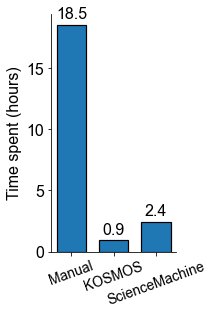

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Example data (replace later)
# =========================
systems = ["Manual", "KOSMOS", "ScienceMachine"]

# Time spent (e.g., hours per analysis project)
time_spent = np.array([18.5, 0.91, 2.4])

# Accuracy (%)
accuracy = np.array([100, 90.5, 80.2])

# Success rate (%)
success_rate = np.array([100.0, 80.0, 60.0])

# Consistency across repeated AI runs (%)
# For manual, set to 100 or np.nan depending on your interpretation
consistency = np.array([100.0, 84.5, 91.3])

# =========================
# Global style
# =========================
plt.rcParams["font.family"] = "Arial"
# plt.rcParams["font.size"] = 12

# =========================
# Figure 1: Time comparison
# =========================
fig, ax = plt.subplots(figsize=(3, 4.5))

x = np.arange(len(systems))
bars = ax.bar(
    x,
    time_spent,
    width=0.7,
    edgecolor="black",
    linewidth=1.2
)

ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=16)
ax.set_ylabel("Time spent (hours)", fontsize=16)
# ax.set_title("Analysis Time Comparison", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=16)
ax.tick_params(axis="x", labelsize=14,rotation = 20)

# add value labels
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.3,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=16
    )

plt.tight_layout()
os.makedirs(figure_path, exist_ok=True)
out_file = os.path.join(figure_path, f"timeSpent_AIvsManual.svg")
plt.savefig(out_file, dpi=600, bbox_inches="tight")
plt.show()




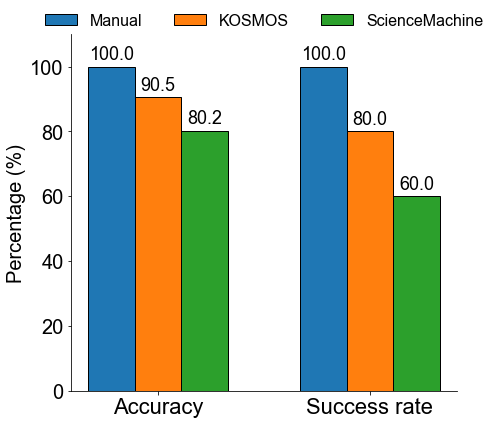

In [110]:
# =========================
# Figure 2: Accuracy / Success / Consistency
# =========================
fig, ax = plt.subplots(figsize=(7, 6))

# metrics = ["Accuracy", "Success rate", "Consistency"]
metrics = ["Accuracy", "Success rate"]
data = np.array([
    accuracy,
    success_rate,
    # consistency
])  # shape = (3 metrics, 3 systems)

n_groups = len(metrics)
n_systems = len(systems)

x = np.arange(n_groups)
bar_width = 0.22

for i in range(n_systems):
    bars = ax.bar(
        x + (i - 1) * bar_width,
        data[:, i],
        width=bar_width,
        label=systems[i],
        edgecolor="black",
        linewidth=1.0
    )
    
    # value labels
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 1.0,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=18
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=20)
ax.set_ylabel("Percentage (%)", fontsize=20)
# ax.set_title("Performance Comparison Across Analysis Systems", fontsize=14)
ax.set_ylim(0, 110)
ax.legend(loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.1), fontsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=22)
ax.tick_params(axis="y", labelsize=20)

plt.tight_layout()
os.makedirs(figure_path, exist_ok=True)
out_file = os.path.join(figure_path, f"AccuConsisSucess_AIvsManual.svg")
plt.savefig(out_file, dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
Accuracy:  

运行了八次，五次成功，三次中途暂停失败

五次中有两次失败了

但是三次成功的结果是否一致呢？ 

得出的结论又是如何呢？ 


